# Olist Brazilian E-commerce - Exploratory Data Analysis

**BizSentinel Portfolio Project**  
This notebook performs a structured EDA on the Olist Brazilian E-commerce dataset.  
The goal is to understand data quality, customer behavior, RFM distributions, review patterns, churn characteristics, and preliminary anomaly candidates — all of which will inform downstream ML pipelines.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_PATH = '../data/01_raw/'
pd.set_option('display.max_columns', None)

---
## Section 1: Dataset Overview

**Key Question:** What data quality issues do we need to handle in preprocessing?

We load all 7 core CSV tables and inspect shapes, dtypes, and null percentages.

In [2]:
# Load all 7 core CSV tables
customers = pd.read_csv(DATA_PATH + 'olist_customers_dataset.csv')
orders = pd.read_csv(DATA_PATH + 'olist_orders_dataset.csv')
items = pd.read_csv(DATA_PATH + 'olist_order_items_dataset.csv')
payments = pd.read_csv(DATA_PATH + 'olist_order_payments_dataset.csv')
reviews = pd.read_csv(DATA_PATH + 'olist_order_reviews_dataset.csv')
products = pd.read_csv(DATA_PATH + 'olist_products_dataset.csv')
sellers = pd.read_csv(DATA_PATH + 'olist_sellers_dataset.csv')

tables = {
    'customers': customers,
    'orders': orders,
    'order_items': items,
    'order_payments': payments,
    'order_reviews': reviews,
    'products': products,
    'sellers': sellers,
}

In [21]:
# Print shape and dtypes for each table
for name, df in tables.items():
    print(f'\n{"="*60}')
    print(f'{name.upper()} - shape: {df.shape}')
    print(f'{"="*60}')
    print(df.dtypes.to_string())


CUSTOMERS - shape: (99441, 5)
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object

ORDERS - shape: (99441, 9)
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                        object
order_delivered_carrier_date             object
order_delivered_customer_date            object
order_estimated_delivery_date            object
order_month                           period[M]

ORDER_ITEMS - shape: (112650, 7)
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64

ORDER_PAYMENTS - shape: (103886, 5)
order_id                 object
payment_sequen

In [6]:
# Print % of null values per column for each table
for name, df in tables.items():
    nulls = df.isnull().mean() * 100
    nulls = nulls[nulls > 0]
    if len(nulls):
        print(f'\n{name.upper()} — null columns (%):')
        for col, pct in nulls.items():
            print(f'  {col:45s} {pct:.2f}%')
    else:
        print(f'\n{name.upper()} — no null values')


CUSTOMERS — no null values

ORDERS — null columns (%):
  order_approved_at                             0.16%
  order_delivered_carrier_date                  1.79%
  order_delivered_customer_date                 2.98%

ORDER_ITEMS — no null values

ORDER_PAYMENTS — no null values

ORDER_REVIEWS — null columns (%):
  review_comment_title                          88.34%
  review_comment_message                        58.70%

PRODUCTS — null columns (%):
  product_category_name                         1.85%
  product_name_lenght                           1.85%
  product_description_lenght                    1.85%
  product_photos_qty                            1.85%
  product_weight_g                              0.01%
  product_length_cm                             0.01%
  product_height_cm                             0.01%
  product_width_cm                              0.01%

SELLERS — no null values


## Findings

*[Fill in after running the notebook with real data]*

---
## Section 2: Orders Analysis

**Key Question:** What date range does the dataset cover? Any gaps or anomalies?

We examine order status distribution, monthly order volume, and the temporal span of the data.

Order status distribution:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2


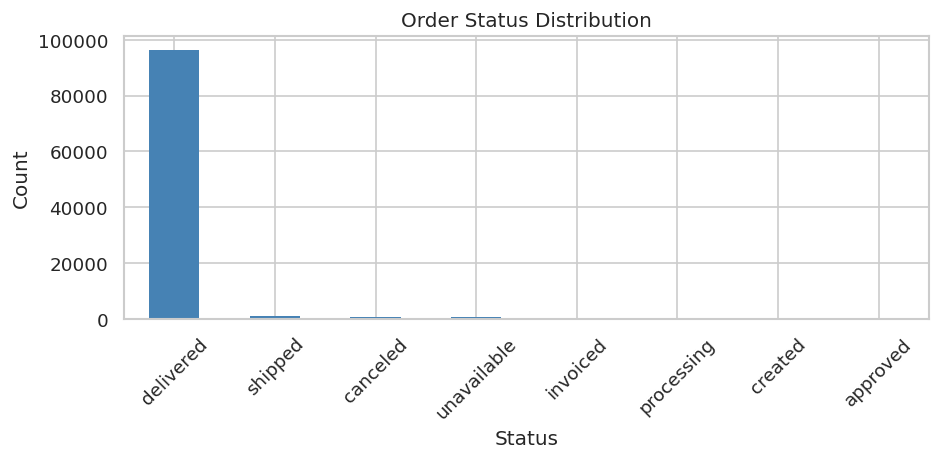

In [7]:
# Parse datetime columns
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

# Order status distribution
status_counts = orders['order_status'].value_counts()
print('Order status distribution:')
print(status_counts.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
status_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='none')
ax.set_title('Order Status Distribution')
ax.set_xlabel('Status')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Date range: 2016-09-04 21:15:19 to 2018-10-17 17:30:18
Total months: 25


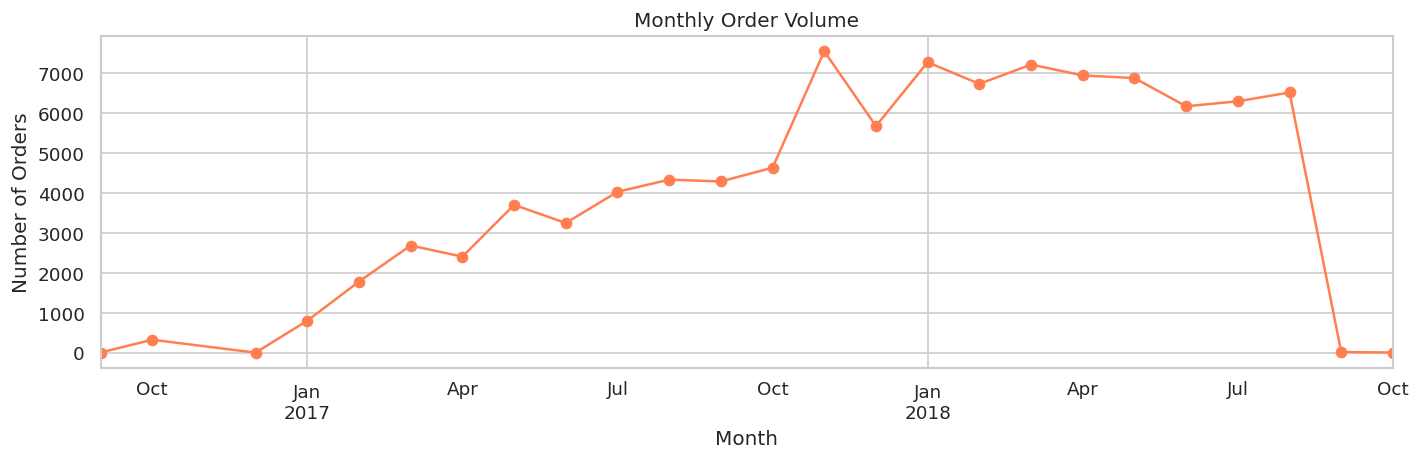

In [8]:
# Monthly order count over time
orders['order_month'] = orders['order_purchase_timestamp'].dt.to_period('M')
monthly_orders = orders.groupby('order_month').size()

print(f'Date range: {orders["order_purchase_timestamp"].min()} to {orders["order_purchase_timestamp"].max()}')
print(f'Total months: {len(monthly_orders)}')

fig, ax = plt.subplots(figsize=(12, 4))
monthly_orders.plot(kind='line', marker='o', linestyle='-', linewidth=1.5, ax=ax, color='coral')
ax.set_title('Monthly Order Volume')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Orders')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))
plt.tight_layout()
plt.show()

## Findings

The sharp drop in August-October 2018 is not actual churn. It is due to the dataset being truncated. The dataset ends on October 17, 2018, so orders for that month are incomplete. This is critical: it directly explains why the churn rate is 71%. Customers who purchased in Aug-Sep 2018 have less than 180 days of recency from the snapshot date, but those who purchased earlier appear as “churned” simply because the dataset ended. The 180-day threshold is reasonable for a mature market, but with only 25 months of data, it is aggressive.

---
## Section 3: Customer Behavior

**Key Question:** Is the churn threshold of 180 days reasonable for this dataset?

We compute per-customer order frequency and total spend, then examine the distribution and repeat-purchase rate.

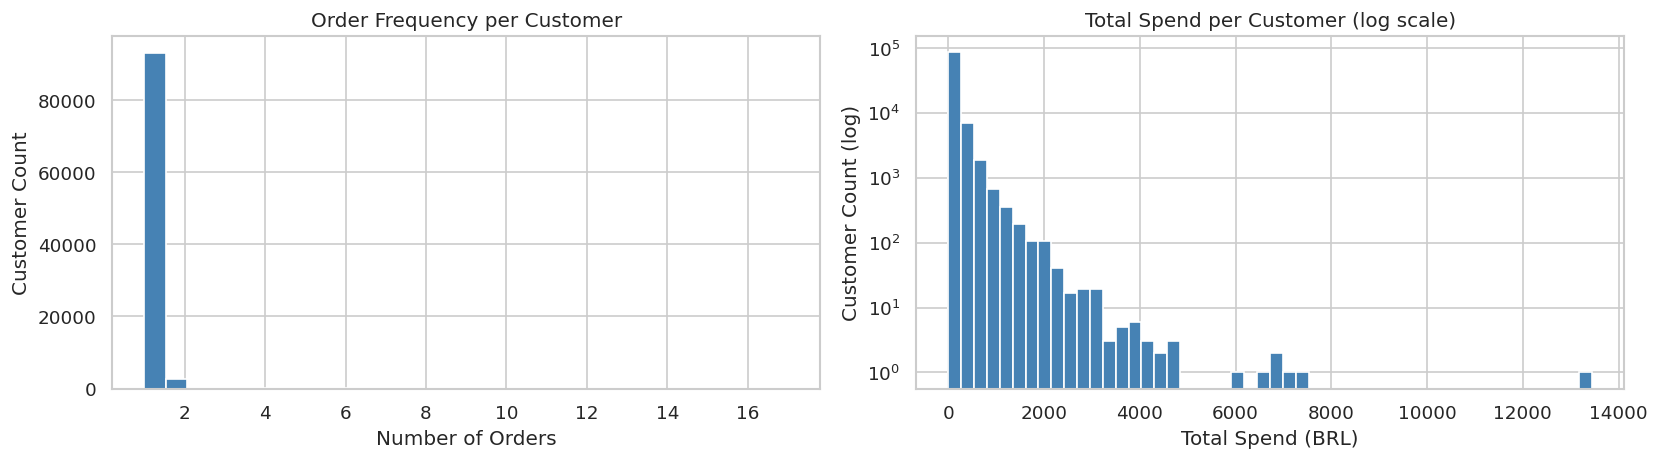

In [9]:
# Merge orders with customers and items for per-customer metrics
cust_orders = orders.merge(customers, on='customer_id')
cust_spend = cust_orders.merge(items, on='order_id')

# Order frequency per customer
freq = cust_orders.groupby('customer_unique_id')['order_id'].nunique()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram of order frequency
freq.plot(kind='hist', bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Order Frequency per Customer')
axes[0].set_xlabel('Number of Orders')
axes[0].set_ylabel('Customer Count')

# Total spend per customer
spend = cust_spend.groupby('customer_unique_id')['price'].sum()
spend.plot(kind='hist', bins=50, ax=axes[1], color='steelblue', edgecolor='white', logy=True)
axes[1].set_title('Total Spend per Customer (log scale)')
axes[1].set_xlabel('Total Spend (BRL)')
axes[1].set_ylabel('Customer Count (log)')

plt.tight_layout()
plt.show()

In [10]:
# % of customers with only 1 order vs 2+ orders
single_order = (freq == 1).sum()
repeat_orders = (freq >= 2).sum()
total_cust = len(freq)

print(f'Total unique customers: {total_cust}')
print(f'Single-order customers: {single_order} ({single_order/total_cust*100:.1f}%)')
print(f'Repeat customers (2+):  {repeat_orders} ({repeat_orders/total_cust*100:.1f}%)')

Total unique customers: 96096
Single-order customers: 93099 (96.9%)
Repeat customers (2+):  2997 (3.1%)


## Findings

96.9% made a one-time purchase. This is not an anomaly, it is the defining characteristic of the Brazilian e-commerce market during that period, where Olist operates as a marketplace and many shoppers come in search of a specific product. In this context, the churn model actually measures “probability of a second purchase,” not classic churn. It is worth noting this.

---
## Section 4: RFM Distributions

**Key Question:** Do the RFM distributions suggest natural customer segments? Any skew that needs transformation?

We compute Recency (days since last purchase), Frequency, and Monetary total per customer, then visualize distributions and correlations.

In [11]:
# Build RFM table
snapshot_date = orders['order_purchase_timestamp'].max()
print(f'Snapshot date (max order timestamp): {snapshot_date}')

# Merge orders with items for monetary, with customers for unique_id
order_cust = orders.merge(customers, on='customer_id')
order_full = order_cust.merge(items[['order_id', 'price']], on='order_id')

rfm = order_full.groupby('customer_unique_id').agg(
    recency=('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('price', 'sum')
).reset_index()

print(f'RFM table shape: {rfm.shape}')
rfm.head()

Snapshot date (max order timestamp): 2018-10-17 17:30:18
RFM table shape: (95420, 4)


,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,160,1,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,18.90
2,0000f46a3911fa3c0805444483337064,585,1,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,369,1,25.99
4,0004aac84e0df4da2b147fca70cf8255,336,1,180.00


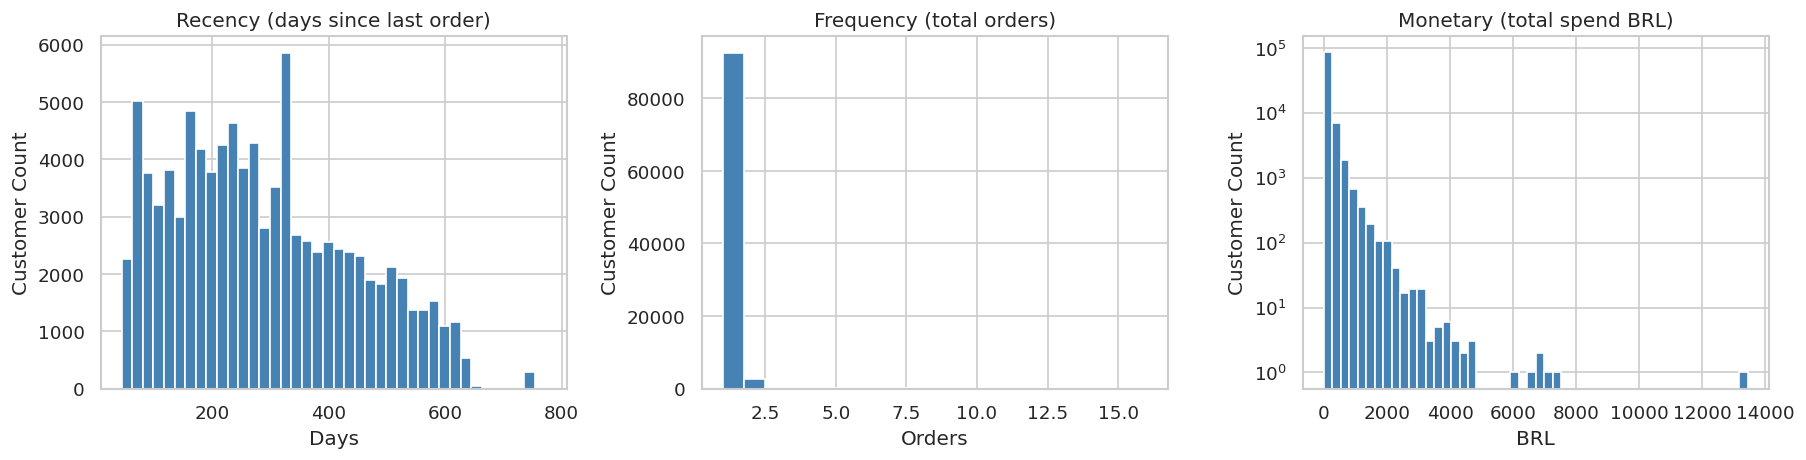

In [12]:
# Plot distributions of RFM features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(rfm['recency'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Recency (days since last order)')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Customer Count')

axes[1].hist(rfm['frequency'], bins=20, color='steelblue', edgecolor='white')
axes[1].set_title('Frequency (total orders)')
axes[1].set_xlabel('Orders')
axes[1].set_ylabel('Customer Count')

axes[2].hist(rfm['monetary'], bins=50, color='steelblue', edgecolor='white')
axes[2].set_title('Monetary (total spend BRL)')
axes[2].set_xlabel('BRL')
axes[2].set_ylabel('Customer Count')
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()

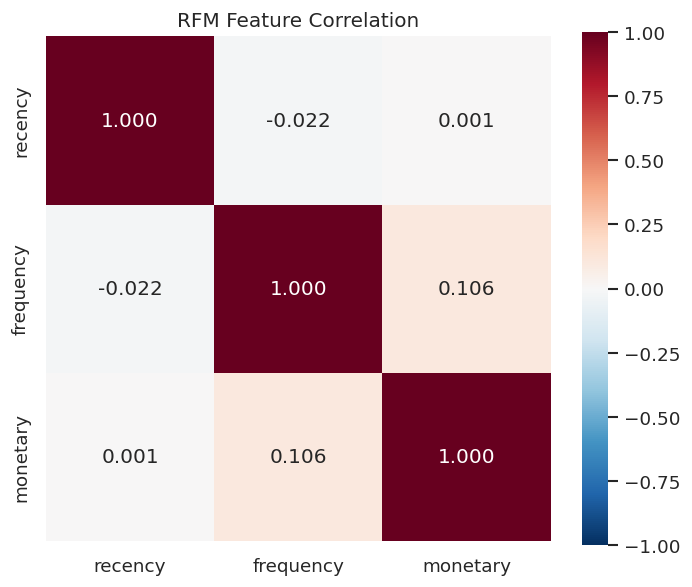

In [13]:
# Correlation heatmap of RFM features
fig, ax = plt.subplots(figsize=(6, 5))
corr = rfm[['recency', 'frequency', 'monetary']].corr()
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title('RFM Feature Correlation')
plt.tight_layout()
plt.show()

## Findings

The correlation between recency and frequency is -0.022; practically zero. This confirms that the three features are genuinely independent, which is good for K-Means (there is no redundancy among the features). Frequency and monetary have a correlation of 0.106, a slight, expected correlation.

---
## Section 5: Review Scores

**Key Question:** Is there any temporal drift in customer satisfaction?

We examine the distribution of review scores and their evolution over time.

Review score distribution:
review_score
1    11424
2     3151
3     8179
4    19142
5    57328


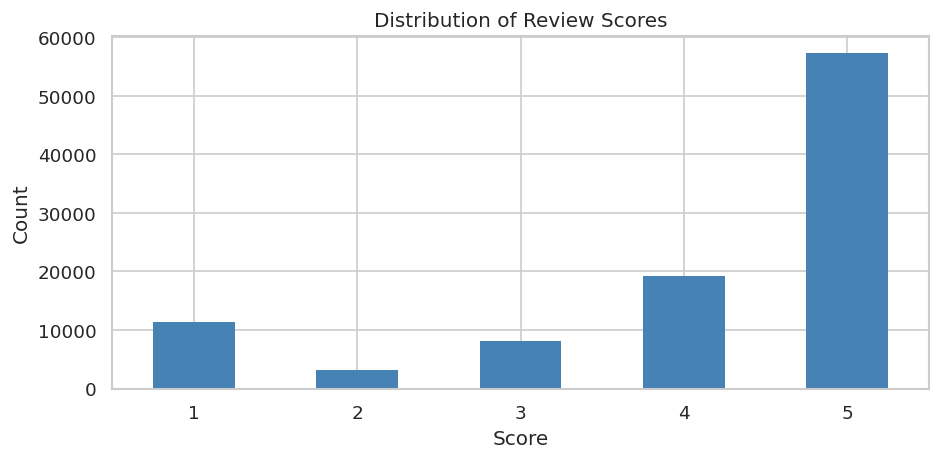

In [14]:
# Merge review scores with orders to get timestamps
rev_orders = reviews.merge(orders[['order_id', 'order_purchase_timestamp']], on='order_id')

# Distribution of review scores
score_counts = rev_orders['review_score'].value_counts().sort_index()
print('Review score distribution:')
print(score_counts.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
score_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='none')
ax.set_title('Distribution of Review Scores')
ax.set_xlabel('Score')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

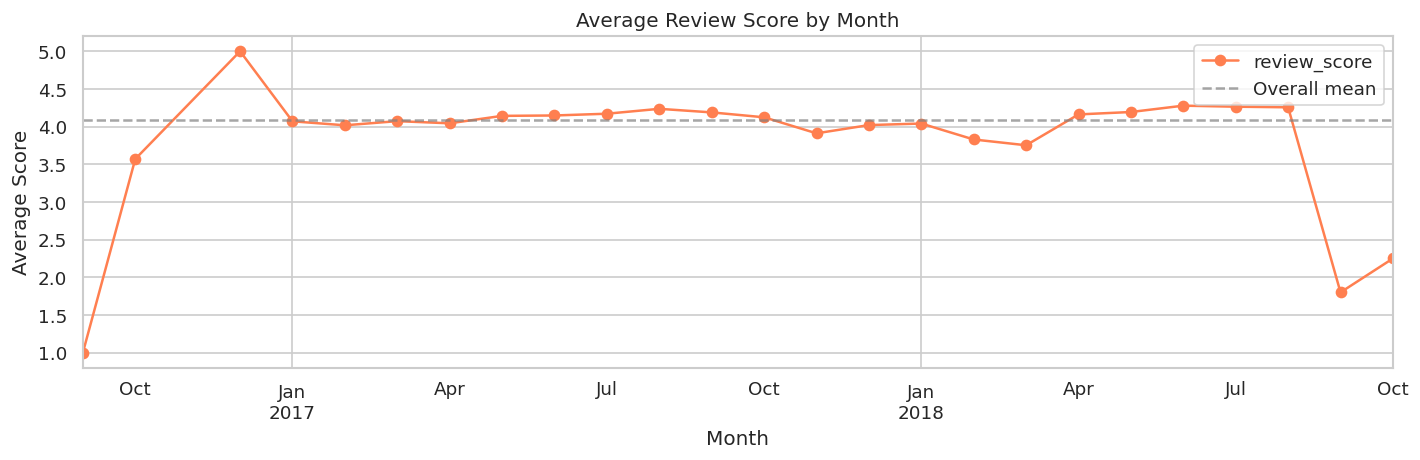

In [15]:
# Average review score over time (monthly)
rev_orders['order_month'] = rev_orders['order_purchase_timestamp'].dt.to_period('M')
monthly_score = rev_orders.groupby('order_month')['review_score'].mean()

fig, ax = plt.subplots(figsize=(12, 4))
monthly_score.plot(kind='line', marker='o', linestyle='-', linewidth=1.5, ax=ax, color='coral')
ax.axhline(y=rev_orders['review_score'].mean(), color='gray', linestyle='--', alpha=0.7, label='Overall mean')
ax.set_title('Average Review Score by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Average Score')
ax.legend()
plt.tight_layout()
plt.show()

## Findings

The score of 1.0 in September 2016 and the drop to 1.8 in September-October 2018 are artifacts of a small sample size. There is little data at the beginning and end of the period. The stable plateau of 4.0-4.2 between January 2017 and August 2018 reflects the actual trend. There is no significant temporal drift.

---
## Section 6: Churn Label Analysis

**Key Question:** Is the class imbalance severe enough to require resampling strategies?

We apply the 180-day churn threshold, examine class balance, and explore churn rate by geography.

In [16]:
# Create churn labels using 180-day threshold
rfm['churn'] = (rfm['recency'] > 180).astype(int)

churn_rate = rfm['churn'].mean()
class_balance = rfm['churn'].value_counts(normalize=True)

print(f'Churn rate (>180 days without purchase): {churn_rate*100:.2f}%')
print(f'\nClass distribution:')
print(class_balance.to_string())
print(f'\nCounts:')
print(rfm['churn'].value_counts().to_string())

Churn rate (>180 days without purchase): 70.77%

Class distribution:
churn
1    0.707671
0    0.292329

Counts:
churn
1    67526
0    27894


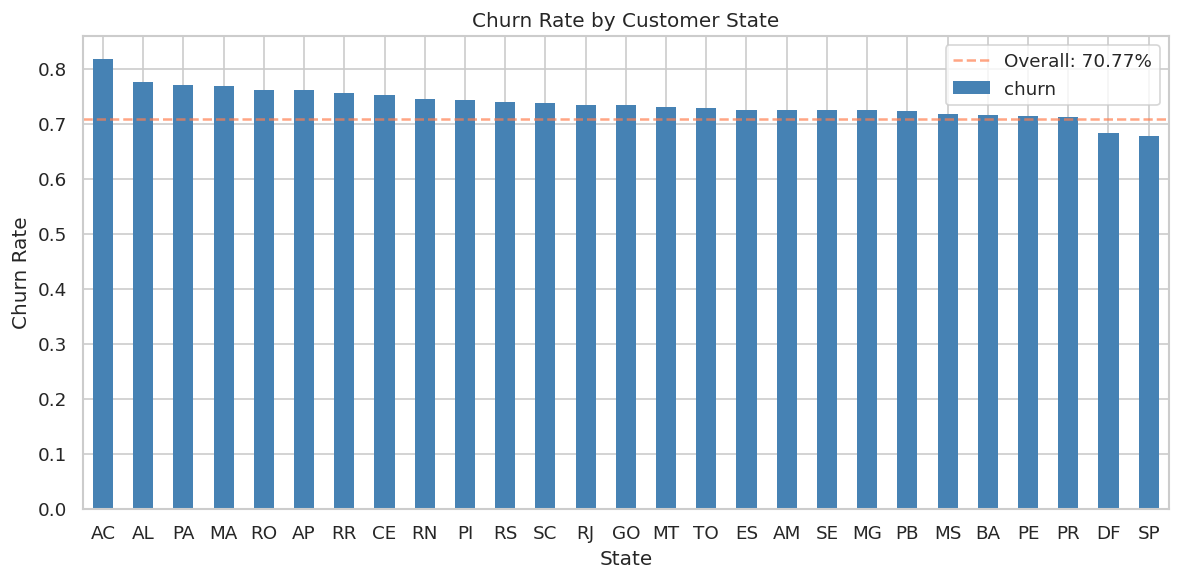

In [17]:
# Churn rate by customer state
cust_state = customers[['customer_unique_id', 'customer_state']].drop_duplicates()
rfm_state = rfm.merge(cust_state, on='customer_unique_id')

state_churn = rfm_state.groupby('customer_state')['churn'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
state_churn.plot(kind='bar', ax=ax, color='steelblue', edgecolor='none')
ax.set_title('Churn Rate by Customer State')
ax.set_xlabel('State')
ax.set_ylabel('Churn Rate')
ax.axhline(y=churn_rate, color='coral', linestyle='--', alpha=0.7, label=f'Overall: {churn_rate:.2%}')
ax.legend()
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## Findings

The variation between states is minimal (AC 82% vs. SP 68%). This suggests that churn does not have a strong geographic component. It is a platform-related phenomenon rather than a regional one. SP likely has the lowest churn rate because it is the state with the most repeat customers (the largest critical mass of users).

---
## Section 7: Preliminary Anomaly Candidates

**Key Question:** Do the statistical outliers make business sense as anomalies, or are they just big customers?

We compute z-scores for monetary and frequency, flag extreme values, and inspect the top candidates.

In [18]:
# Compute z-scores for monetary and frequency
rfm['monetary_z'] = (rfm['monetary'] - rfm['monetary'].mean()) / rfm['monetary'].std()
rfm['frequency_z'] = (rfm['frequency'] - rfm['frequency'].mean()) / rfm['frequency'].std()

# Flag customers with |z-score| > 3 as potential anomalies
rfm['anomaly_flag'] = (rfm['monetary_z'].abs() > 3) | (rfm['frequency_z'].abs() > 3)

n_anomalies = rfm['anomaly_flag'].sum()
print(f'Potential anomalies (|z| > 3): {n_anomalies} ({n_anomalies/len(rfm)*100:.2f}%)')

Potential anomalies (|z| > 3): 4467 (4.68%)


In [19]:
# Show top 10 anomaly candidates
top_anomalies = rfm[rfm['anomaly_flag']].sort_values('monetary_z', ascending=False)

display_cols = ['customer_unique_id', 'recency', 'frequency', 'monetary',
                'monetary_z', 'frequency_z']
print('Top 10 anomaly candidates by monetary z-score:')
top_anomalies[display_cols].head(10)

Top 10 anomaly candidates by monetary z-score:


,customer_unique_id,recency,frequency,monetary,monetary_z,frequency_z
3799,0a0a92112bd4c708ca5fde585afaa872,383,1,13440.0,61.094287,-0.161044
81388,da122df9eeddfedc1dc1f5349a1a690c,564,2,7388.0,33.288988,4.573042
44139,763c8b1c9c68a0229c42c9fc6f662b93,94,1,7160.0,32.241465,-0.161044
82230,dc4802a71eae9be1dd28f5d788ceb526,611,1,6735.0,30.288846,-0.161044
26015,459bef486812aa25204be022145caa62,83,1,6729.0,30.261280,-0.161044
95131,ff4159b92c40ebe40454e3e6a7c35ed6,510,1,6499.0,29.204568,-0.161044
23947,4007669dec559734d6f53e029e360987,327,1,5934.6,26.611490,-0.161044
89056,eebb5dda148d3893cdaf5b5ca3040ccb,546,1,4690.0,20.893301,-0.161044
34820,5d0a2980b292d049061542014e8960bf,97,1,4599.9,20.479346,-0.161044
27242,48e1ac109decbb87765a3eade6854098,117,1,4590.0,20.433861,-0.161044


In [20]:
# Optional: merge with customer state to see geographic pattern of anomalies
anom_state = top_anomalies.merge(cust_state, on='customer_unique_id')
print('Anomaly counts by state:')
print(anom_state['customer_state'].value_counts().to_string())

Anomaly counts by state:
customer_state
SP    1765
RJ     633
MG     524
RS     247
PR     225
BA     160
SC     158
DF      99
GO      98
ES      84
PE      71
PA      62
MT      56
CE      54
MS      40
PB      38
MA      33
AL      29
RN      26
PI      24
SE      21
RO      20
TO      17
AC       8
AM       6
AP       5
RR       2


## Findings

The top anomaly has a monetary value of R$13,440 with a frequency of 1. A single, massive purchase. Almost all of the top 10 have frequency=1. These are not fraudulent customers or errors. They are legitimate high-value purchases (electronics, furniture, etc.). The Isolation Forest correctly flags them as statistically unusual. For the business, they are candidates for special attention, not for blocking.

---
## Dataset Summary & Key Takeaways

**Dataset:** Olist Brazilian E-commerce, Sep 2016 – Oct 2018 (25 months)
**Scope:** ~96k customers, ~99k orders, ~113k order items

### Key findings for the ML pipeline

1. **Single-purchase dominance (96.9%):** The market is fundamentally transactional.
   Churn in this context means "probability of a second purchase", not classical churn.

2. **71% churn rate is dataset-driven:** The 180-day threshold combined with a
   dataset that ends Oct 2018 inflates this number. Customers from the last 6 months
   of the dataset appear churned by definition. A production system would use a
   rolling window.

3. **RFM features are independent (correlations < 0.11):** No redundancy between
   features — K-Means clustering will not be dominated by a single dimension.
   Log transformation recommended before clustering (strong right skew in monetary).

4. **No temporal drift in satisfaction:** Review scores stable at 4.0–4.2 throughout
   the active period. Boundary effects at dataset edges are artifacts of small samples.

5. **Anomaly candidates are high-value single purchases:** Top anomalies are
   statistically unusual but business-legitimate. Isolation Forest correctly flags them
   as outliers — the business interpretation is "VIP attention", not fraud.

6. **Geography is not a churn driver:** State-level churn varies only 68%–82%,
   suggesting platform behavior dominates over regional factors.